# Example of using Open Data

## Incidence of violent and property crimes and library proximity in Philadelphia

## COMM2550 Spring 2026

### Instructor: Matt O'Donnell (mbod@asc.upenn.edu)

-----

### Background

* The availability and increased funding of public resources, such as recreation centers and branches of public libraries, are frequently mentioned by anti-violence advocates as POSITIVE influences in the reduction of crime in local neighborhoods.

* As an example the branches of the Philadelphia Free Library system have regularly experienced fluctuations in funding and had small periods of time when they are open 6+ days a week.

> “It’s no coincidence that we saw such dramatic spikes in gun violence when our neighborhoods were cut off from virtually every resource they have access to,” said Councilmember Jamie Gauthier (District 3). “We have to see major investments in our young people and our communities as key to our city’s anti-violence work. Libraries are lifelines in our neighborhoods — places for our young people to learn, explore their interests, and have fun in a safe, nurturing environment.”
>
>   https://phlcouncil.com/councilmember-gym-leads-call-for-libraries-to-open-six-days-a-week/

#### Historical test case 

* During 3 months at the end of 2019 most of the branches of the Free Library system received extra funding to be open 6 days a week. We can compare crime statistics from this period to an equivalent period in 2017 when the libraries did not have this extra funding, so were not open 6 days a week.

----------

* __Research Question__: _What impact does the presence AND accessibility (i.e. being open 6 days a week) of public libraries have on the incidence of violent crime?_

* __Hypothesis__: Switching to 6 day opening will reduce the amount of violent crime within a half mile radius of a library branch.

------



### Setup

* We are going to use Python for this example.

* First we need to setup the notebook with the libraries (sets of code recipes) we need to use.

In [1]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

* Through https://www.opendataphilly.org/ the Philadelphia Police Department (PPD) publishes: 


> Crime incidents from the Philadelphia Police Department. Part I crimes include violent offenses such as aggravated assault, rape, arson, among others. Part II crimes include simple assault, prostitution, gambling, fraud, and other non-violent offenses.
>
> https://www.opendataphilly.org/dataset/crime-incidents


* Here we are going to focus on the following categories of crime.

In [2]:
'''
UCR General Codes for violent crimes:
100 - Homicide
200 - Rape
300 - Robbery
400 - Aggragated Assault
'''

VIOLENT= [100, 200, 300, 400]

* Set up a function to load the data we need

In [3]:
def load_crime_data(year, ucr_filter=None):
    '''load the CSV for crimes for specific year and apply UCR filter
    '''
    fpath = os.path.join('data/crime_data','crime_data_{}.csv'.format(year))
                         
    if not os.path.exists(fpath):
        print(fpath)
        return None
                         
    df = pd.read_csv(fpath,  low_memory=False)
    
    # filter out geo-location errors
    outside_bounds=df['point_x']<-76
    df = df[-outside_bounds]
    
    if ucr_filter:
        df = df[df['ucr_general'].isin(ucr_filter)]
    
    return df

### Taking a look at violent crime data in 2017

* To understand what the data looks like. Let's take a look at the data for 2017 filtered for crimes in the categories listed above.

In [4]:
v2017=load_crime_data('2017', ucr_filter=VIOLENT)
v2017_gpd = gpd.GeoDataFrame(v2017, geometry=gpd.points_from_xy(x=v2017['lng'], y=v2017['lat']))
v2017_gpd.crs='epsg:4326'

* Let's plot a random sample of 1000 incidents and plot them

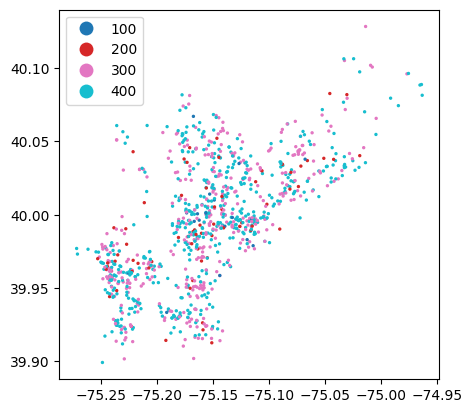

In [5]:
v2017_gpd.sample(1000).plot(markersize=2, column='ucr_general', 
       categorical=True, legend=True)
plt.show()

### Where are the libraries in Philadelphia?

* Next we want to know where the Free Library branches are.

In [6]:
libraries_gpd = gpd.read_file('data/PHL_freelibrary.geojson')
libraries_gpd = libraries_gpd.to_crs(crs=4326) 
zip_gpd=gpd.read_file('data/Zipcodes_Poly.geojson').to_crs(crs=4326)
libraries_gpd.shape

(53, 9)

* There are 53 libraries in the PHL Free Library system
* Where are they?

In [7]:
libraries_gpd[['id','name','lat','lon']].set_index('id')

,name,lat,lon
id,,,
location-AND,Andorra Library,40.064287,-75.239392
location-COB,Blanche A. Nixon/Cobbs Creek Library,39.918046,-75.246178
location-BHR,Bushrod Library,40.038595,-75.078576
location-BUS,Bustleton Library,40.108392,-75.026133
location-CBM,Cecil B. Moore Library,39.980559,-75.172939
location-DUR,Charles L. Durham Library,39.964089,-75.190536
location-SWK,Charles Santore Library,39.937091,-75.155261
location-CHH,Chestnut Hill Library,40.077738,-75.209763
location-OGN,David Cohen Ogontz Library,40.046765,-75.150839


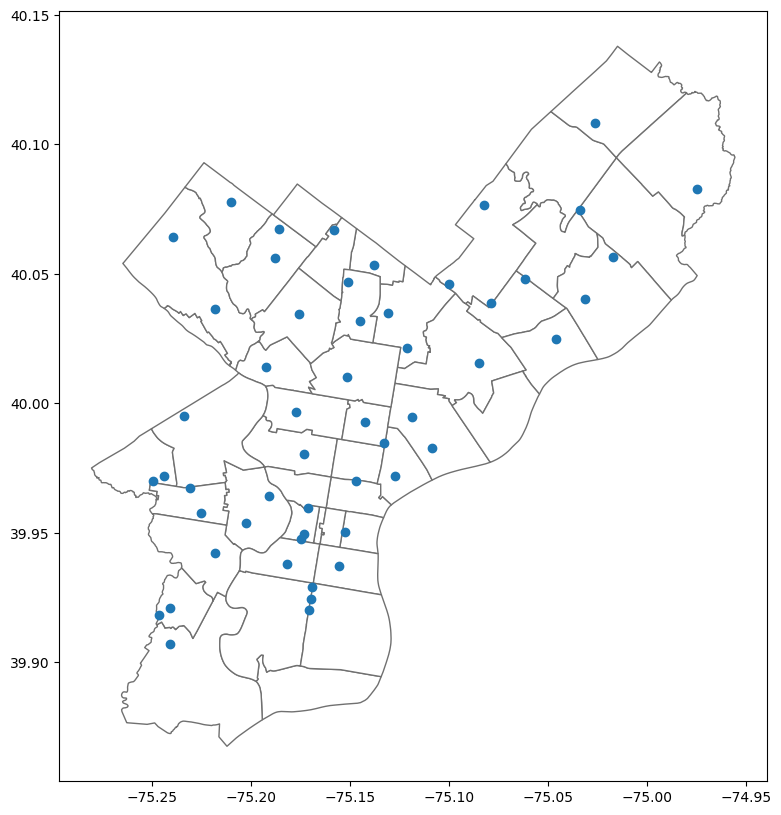

In [8]:
base = zip_gpd.plot(color='white', edgecolor='#707070', figsize=(10,10))
libraries_gpd.plot(ax=base)
plt.show()

### Measuring the impact of the presence of a library

* A simple (but crude and imprecise) measure of the impact of the physical presence of a library branch could be to:
    1. look within a half a mile radius of the branch
    2. and count the number of violent crimes that occur in a particular time window
    
* Here are the locations of the libraries with a 800 meter buffer

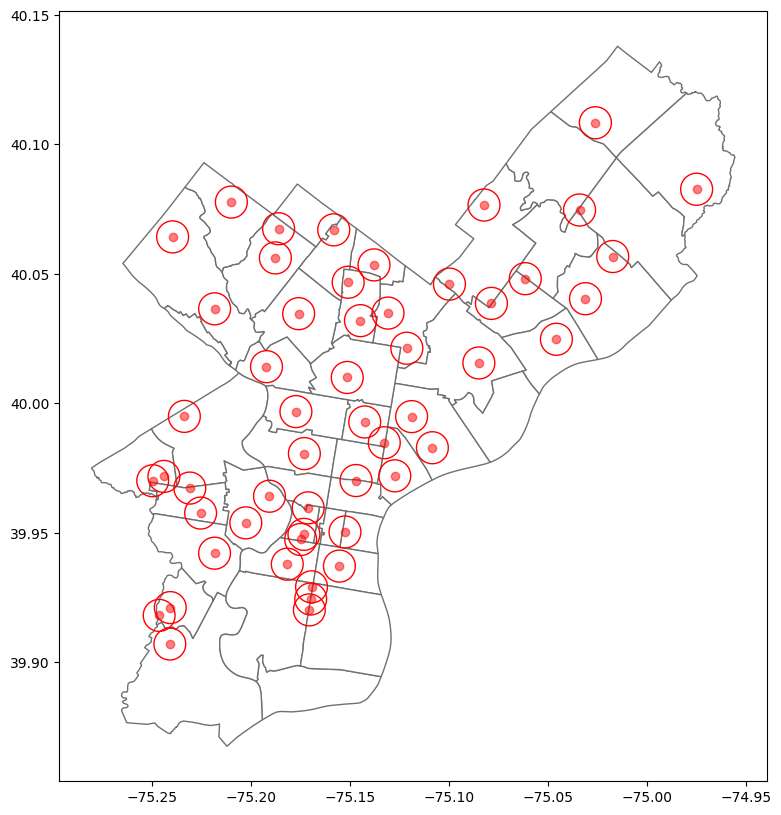

In [9]:
base = zip_gpd.plot(color='white', edgecolor='#707070', figsize=(10,10))
libraries_gpd['geometry'].plot(ax=base, alpha=0.5, color='red')
libraries_gpd['geometry'].to_crs(epsg=7855).buffer(800).to_crs(epsg=4326).plot(ax=base, edgecolor='red', facecolor='none')
plt.show()

#### Intersect zones around branches with crime incident data

__Time window__

* Oct-Dec 2017 compared to Oct-Dec 2019

In [10]:
# 1. construct buffer zones around library branches
lzone_gpd = libraries_gpd.copy()
lzone_gpd['geometry'] = lzone_gpd['geometry'].to_crs(epsg=7855).buffer(800).to_crs(epsg=4326)

# 2. load 2019 data
v2019 = load_crime_data('2019', VIOLENT)
v2019_gpd = gpd.GeoDataFrame(v2019, geometry=gpd.points_from_xy(x=v2019['lng'], y=v2019['lat']))
v2019_gpd.crs='epsg:4326'

# 3. subset crime data for 2017 and 2019 for Oct to Dec only
oct1 = dt.datetime.strptime('2017-10-01','%Y-%m-%d')
v2017_post=v2017_gpd[pd.to_datetime(v2017_gpd['dispatch_date'])>=oct1]

sixdaystart=dt.datetime.strptime('2019-10-01','%Y-%m-%d')
v2019_post=v2019_gpd[pd.to_datetime(v2019_gpd['dispatch_date'])>=sixdaystart]

# 4. subset crime data with geographic buffer zones
isect2017 = gpd.sjoin(lzone_gpd, v2017_post)
isect2019 = gpd.sjoin(lzone_gpd, v2019_post)

# 5. count the number of crimes in time period and buffer zone
ccnt2017=pd.DataFrame(isect2017.groupby('id')['full_address'].count()).rename(columns={'full_address':'crime_cnt2017'})
ccnt2019=pd.DataFrame(isect2019.groupby('id')['full_address'].count()).rename(columns={'full_address':'crime_cnt2019'})

In [11]:
ccnt2017

,crime_cnt2017
id,
location-AND,2
location-BHR,27
location-BUS,7
location-CBM,66
location-CEN,18
location-CHH,1
location-COB,9
location-DUR,24
location-ESW,8


In [12]:
# 6. calculate the change (delta) between 2019 and 2017 by zone

lzone_gpd.to_crs('epsg:4326',inplace=True)
lzone_gpd=lzone_gpd.merge(ccnt2017, on='id').merge(ccnt2019, on='id')
lzone_gpd['change_percent'] = (lzone_gpd['crime_cnt2019'] - lzone_gpd['crime_cnt2017']) / lzone_gpd['crime_cnt2017']*100

In [13]:
lzone_gpd[['id','change_percent']].round(1)

,id,change_percent
0,location-COB,77.8
1,location-BHR,-3.7
2,location-BUS,-28.6
3,location-CBM,-21.2
4,location-DUR,-20.8
5,location-SWK,20.0
6,location-OGN,-2.9
7,location-ESW,0.0
8,location-FAL,-60.0
9,location-FSH,85.7


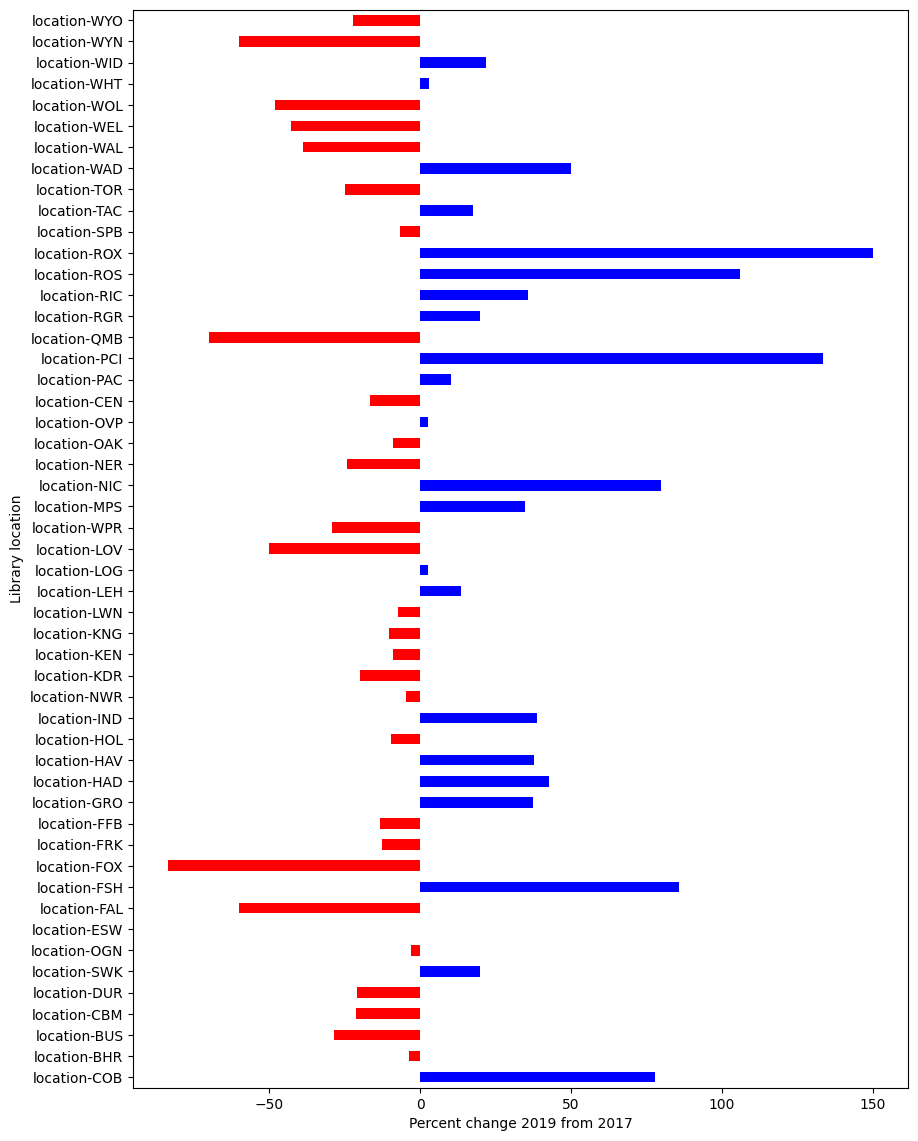

In [14]:
bar_color=lzone_gpd.set_index('id')['change_percent'].apply(lambda v: 'red' if v<0 else 'blue')
lzone_gpd.set_index('id')['change_percent'].plot(kind='barh', color=bar_color, figsize=(10,14))
plt.xlabel('Percent change 2019 from 2017')
plt.ylabel('Library location')
plt.show()

In [15]:
(lzone_gpd['change_percent']<0).value_counts()

change_percent
True     28
False    23
Name: count, dtype: int64

* So no marked pattern of reduction 

* But we could plot these change data back onto a map like this

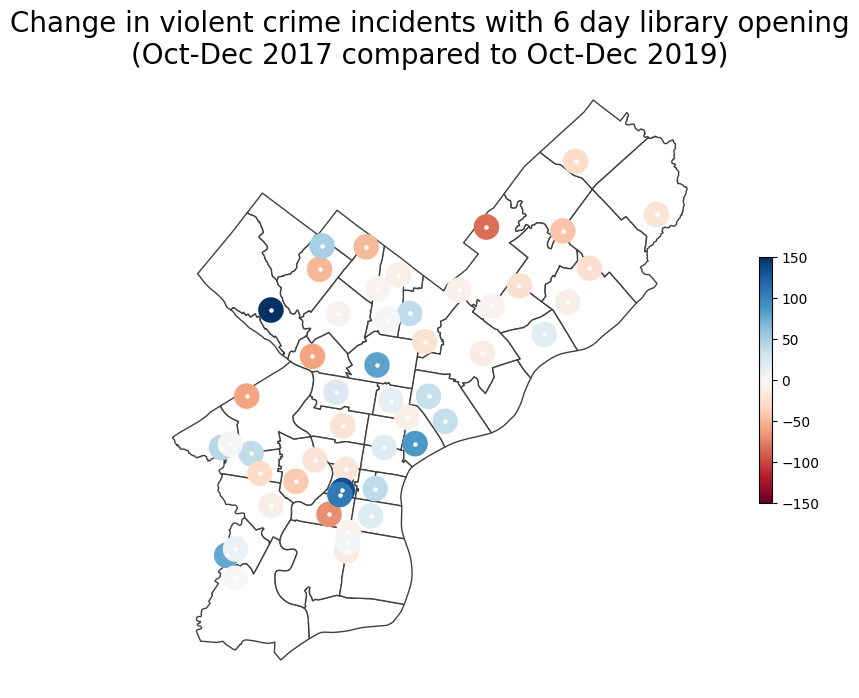

In [16]:
fig, ax = plt.subplots(figsize  = (12, 8))

norm = mpl.colors.Normalize(-150,150,clip=True)

base = zip_gpd.plot(ax=ax, color='white', edgecolor='#404040')
lzone_gpd.plot(ax=base,column='change_percent',legend=True, 
               cmap="RdBu", norm=norm,
               legend_kwds={'shrink': 0.4})

libraries_gpd.plot(ax=base, color='white', markersize=5)

ax.set_title("Change in violent crime incidents with 6 day library opening\n(Oct-Dec 2017 compared to Oct-Dec 2019)", fontsize=20)
ax.set_axis_off()